# Lab 05：學到的 score 準不準？

對應講義：[第 05 課](../lessons/05_score_and_sde.md)

資料換成第 02 課的 8 個高斯排成一圈。它的好處是：**加了任何程度的雜訊之後，精確的 score 都算得出來**（`GaussianMixture.diffused`）。
所以我們可以拿「DDPM 網路換算出的 score」（式 5.2）去對答案：

1. 在不同雜訊等級，把學到的 score 和精確 score 並排畫出來
2. 畫誤差地圖：哪裡學得準、哪裡不準？（呼應第 02 課 §2.4）
3. 同一個模型，用反向 SDE（DDPM）和 probability flow ODE 取樣，比較軌跡

CPU 約 3 分鐘。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


## 1. 在常態混合上訓練 DDPM

In [2]:
from diffusion_course.data import GaussianMixture
from diffusion_course.ddpm import ddpm_loss
from diffusion_course.models import ToyMLP
from diffusion_course.schedules import NoiseSchedule
from diffusion_course.training import train
from diffusion_course.viz import new_axes, plot_points, plot_vector_field

TRAIN_STEPS = 5000
mixture = GaussianMixture.ring(num_components=8, radius=2.0, std=0.15)
schedule = NoiseSchedule.create("linear", 1000)


def mixture_batches(batch_size: int = 512):
    while True:
        yield mixture.sample(batch_size), None


model = ToyMLP()
result = train(model, lambda m, x, y: ddpm_loss(m, schedule, x, y), mixture_batches(), TRAIN_STEPS, lr=1e-3, log_every=1000)
ema_model = result.sampling_model
print(f"trained in {result.seconds:.0f}s")

step 1000/5000  loss 0.2837


step 2000/5000  loss 0.2622


step 3000/5000  loss 0.2465


step 4000/5000  loss 0.2433


step 5000/5000  loss 0.2447


trained in 75s


## 2. 學到的 score 對照精確 score

學到的 score：$s_\theta(x, t) = -\epsilon_\theta(x, t) / \sqrt{1-\bar\alpha_t}$（式 5.2）。
精確的 score：`mixture.diffused(alpha_bar).score`。上排是學到的，下排是精確的；箭頭只畫方向。

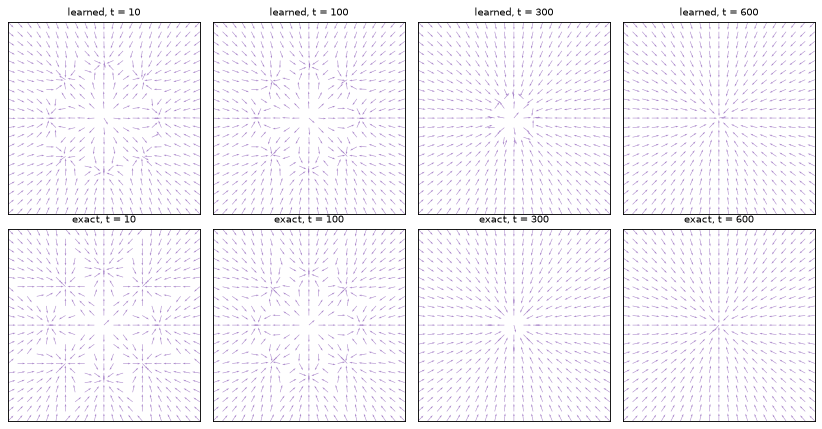

In [3]:
from diffusion_course.score import eps_to_score


def learned_score(x: torch.Tensor, step: int) -> torch.Tensor:
    t = torch.full((len(x),), step)
    with torch.no_grad():
        eps = ema_model(x, schedule.timestep_input(t))
    return eps_to_score(eps, 1 - schedule.alpha_bars[step])


def exact_score(x: torch.Tensor, step: int) -> torch.Tensor:
    return mixture.diffused(schedule.alpha_bars[step].item()).score(x)


steps = [10, 100, 300, 600]
fig, axes = plt.subplots(2, len(steps), figsize=(2.6 * len(steps), 5.4))
for col, step in enumerate(steps):
    plot_vector_field(lambda x: learned_score(x, step), axes[0, col], title=f"learned, t = {step}", normalize=True)
    plot_vector_field(lambda x: exact_score(x, step), axes[1, col], title=f"exact, t = {step}", normalize=True)
plt.tight_layout()
plt.show()

## 3. 誤差地圖：哪裡學得準？

在網格上計算誤差 $\|s_\theta - s\|$，除以「這個雜訊等級下 score 的典型大小」（資料上的均方根），讓不同 $t$ 可以放在同一個色階比較。
（不用逐點的相對誤差 $\|s_\theta - s\|/\|s\|$：在真實 score 剛好接近 0 的地方，例如密度的山頂，它會爆掉，畫出假的高誤差。）
白線是該雜訊等級下資料密度的等高線。另外分別算兩種平均：**照資料分布加權**（取樣時實際會經過的地方）和**整個畫面均勻平均**。

t =  10: mean error where the data is = 0.125   over the whole square = 1.100
t = 100: mean error where the data is = 0.080   over the whole square = 0.582


t = 300: mean error where the data is = 0.023   over the whole square = 0.064
t = 600: mean error where the data is = 0.017   over the whole square = 0.066


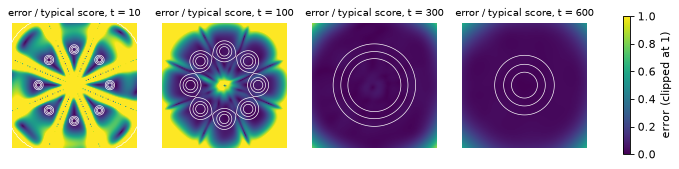

In [4]:
LIMIT = 3.5
axis = torch.linspace(-LIMIT, LIMIT, 120)
xs, ys = torch.meshgrid(axis, axis, indexing="xy")
grid = torch.stack([xs.flatten(), ys.flatten()], dim=1)

fig, axes = plt.subplots(1, len(steps), figsize=(2.9 * len(steps), 2.8))
for ax, step in zip(axes, steps):
    noisy = mixture.diffused(schedule.alpha_bars[step].item())
    samples = noisy.sample(5000)
    scale = exact_score(samples, step).norm(dim=1).pow(2).mean().sqrt()

    grid_error = (learned_score(grid, step) - exact_score(grid, step)).norm(dim=1) / scale
    data_error = (learned_score(samples, step) - exact_score(samples, step)).norm(dim=1) / scale

    density = noisy.log_prob(grid).exp().reshape(120, 120)
    image = ax.imshow(grid_error.reshape(120, 120).clamp(max=1.0), origin="lower", extent=(-LIMIT, LIMIT, -LIMIT, LIMIT), cmap="viridis", vmin=0, vmax=1)
    ax.contour(xs, ys, density, levels=4, colors="white", linewidths=0.6)
    ax.set_title(f"error / typical score, t = {step}", fontsize=9)
    ax.axis("off")
    print(f"t = {step:>3}: mean error where the data is = {data_error.mean():.3f}   over the whole square = {grid_error.mean():.3f}")
fig.colorbar(image, ax=axes, shrink=0.8, label="error (clipped at 1)")
plt.show()

讀圖：

- **$t$ 小**（雜訊少）：資料集中在 8 個小圓附近，那裡的誤差很小；**遠離資料的地方（各群之間與外圍）誤差都很大**——網路幾乎沒在那裡看過 $x_t$，只能外插。$t = 10$ 時資料附近的平均誤差約 0.13，整個畫面平均卻超過 1。這正是第 02 課 §2.4 的問題 2。
- **$t$ 大**：加噪後的分布鋪滿整個畫面，score 到處都學得準。

DDPM 取樣時，粒子在 $t$ 大時四處分布（那時 score 到處都準），隨著 $t$ 變小才靠近資料（那時 score 在資料附近準）——**取樣路徑恰好一直走在 score 準確的區域**。這就是多雜訊等級設計的精妙之處。

## 4. Tweedie：$\hat x_0$ 是條件期望

常態混合的 $\mathbb{E}[x_0 \mid x_t]$ 也有精確解（式 5.3 代入精確 score）。拿網路的 `predict_x0` 對答案：

In [5]:
from diffusion_course.ddpm import predict_x0, q_sample

for step in [50, 300, 600]:
    x0 = mixture.sample(5000)
    t = torch.full((len(x0),), step)
    x_t = q_sample(schedule, x0, t, torch.randn_like(x0))
    alpha_bar = schedule.alpha_bars[step]
    tweedie = (x_t + (1 - alpha_bar) * exact_score(x_t, step)) / alpha_bar.sqrt()
    with torch.no_grad():
        network = predict_x0(schedule, x_t, t, ema_model(x_t, schedule.timestep_input(t)))
    gap = (network - tweedie).norm(dim=1).mean()
    spread = tweedie.std(dim=0).mean()
    print(f"t = {step:>3}: mean |network x0_hat - exact E[x0|x_t]| = {gap:.3f}   (spread of E[x0|x_t] itself: {spread:.3f})")

t =  50: mean |network x0_hat - exact E[x0|x_t]| = 0.018   (spread of E[x0|x_t] itself: 1.416)
t = 300: mean |network x0_hat - exact E[x0|x_t]| = 0.029   (spread of E[x0|x_t] itself: 1.108)
t = 600: mean |network x0_hat - exact E[x0|x_t]| = 0.147   (spread of E[x0|x_t] itself: 0.318)


## 5. 反向 SDE vs. probability flow ODE

同一個網路、同一份起始雜訊，兩種取樣方式：

- **反向 SDE**：`ddpm_sample`，每步加雜訊。
- **Probability flow ODE**：`ddim_sample(eta=0, num_steps=1000)`，完全確定（第 07 課會解釋為什麼 DDIM 是式 5.6 的離散化）。

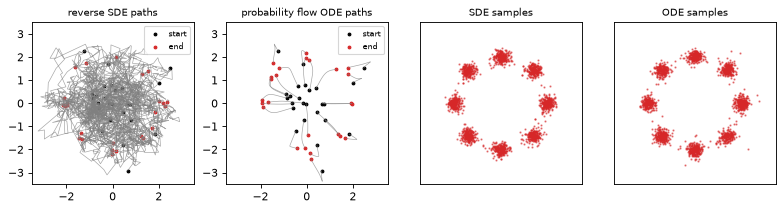

target fraction per component: 0.125
SDE: [0.137, 0.122, 0.132, 0.121, 0.124, 0.127, 0.12, 0.117]
ODE: [0.146, 0.125, 0.128, 0.114, 0.12, 0.134, 0.127, 0.104]


In [6]:
from diffusion_course.ddim import ddim_sample
from diffusion_course.ddpm import ddpm_sample
from diffusion_course.viz import plot_trajectories

noise = torch.randn(2000, 2)
sde_samples, sde_path = ddpm_sample(ema_model, schedule, (2000, 2), noise=noise, save_every=10)
ode_samples, ode_path = ddim_sample(ema_model, schedule, (2000, 2), num_steps=1000, eta=0.0, noise=noise, return_trajectory=True)

axes = new_axes(4, size=3)
plot_trajectories(sde_path, axes[0], num_paths=25)
axes[0].set_title("reverse SDE paths", fontsize=9)
plot_trajectories(ode_path[::10], axes[1], num_paths=25)
axes[1].set_title("probability flow ODE paths", fontsize=9)
plot_points(sde_samples, axes[2], "SDE samples", color="tab:red")
plot_points(ode_samples, axes[3], "ODE samples", color="tab:red")
plt.show()


def component_fractions(points: torch.Tensor) -> list[float]:
    nearest = torch.cdist(points, mixture.means).argmin(dim=1)
    return [round(f, 3) for f in (torch.bincount(nearest, minlength=8).float() / len(points)).tolist()]


print("target fraction per component: 0.125")
print("SDE:", component_fractions(sde_samples))
print("ODE:", component_fractions(ode_samples))

**確定性**：ODE 從同一份雜訊出發，每次都走到同一個點；SDE 不會。

In [7]:
ode_again = ddim_sample(ema_model, schedule, (2000, 2), num_steps=1000, eta=0.0, noise=noise)
sde_again = ddpm_sample(ema_model, schedule, (2000, 2), noise=noise)
print(f"ODE, same noise twice: max difference = {(ode_again - ode_samples).abs().max():.2e}")
print(f"SDE, same noise twice: mean difference = {(sde_again - sde_samples).norm(dim=1).mean():.3f}")

ODE, same noise twice: max difference = 0.00e+00
SDE, same noise twice: mean difference = 2.566


## 小結

- DDPM 的雜訊預測器換算一下就是 score（式 5.2）；它只在「該雜訊等級的資料會出現的地方」準確，而取樣路徑恰好一直走在那些地方。
- 網路的 $\hat x_0$ 就是 Tweedie 公式裡的條件期望。
- 同一個模型可以用隨機的反向 SDE 或確定的 probability flow ODE 取樣，得到相同的分布；ODE 的路徑平滑且可重現。

下一課把這一切搬到影像上。